## 1. Setup and Dependencies

In [0]:
!pip install lightgbm
!pip install catboost

Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

In [0]:
from pyspark.sql import SparkSession# --------------------------------------

#  Initialize Spark
# --------------------------------------
spark = SparkSession.builder \
    .appName("SNI ML Dataset Preparation") \
    .enableHiveSupport() \
    .getOrCreate()

## 2. Load Dataset

In [0]:
# ====  Load the origin table ====
sni_df = spark.read.table(
    "supplychain.shipped_not_invoiced.fact_enterprise_shipped_not_invoiced_legacy_combined_reporting_view"
)
print(f"Loaded rows: {sni_df.count():,}")

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:136)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecutio

In [0]:
sni_df.columns

['Order_Scenario',
 'Source_System_Identifier',
 'Logical_Deletion_Indicator',
 'Insert_GMT_Timestamp',
 'Update_GMT_Timestamp',
 'Load_Job_Number',
 'Source_System_Extract_GMT_Timestamp',
 'Source_System_Update_Timestamp',
 'Sales_Order_Type_Code',
 'Sales_Order_Identifier',
 'Sales_Order_Line_Item_Identifier',
 'Sales_Order_Line_Item_Product_Id',
 'Sales_Order_Line_Item_Quantity',
 'Sold_To_Party',
 'Ship_To_Party_Header',
 'Plant_Code',
 'Shipping_Point_Code',
 'Sales_Office_Code',
 'Sales_Organization_Code',
 'Sales_Order_Distribution_Channel_Code',
 'Sales_Order_Schedule_Line_Material_Availability_Date',
 'Sales_Order_Header_Create_Date',
 'Header_User_Status',
 'Item_User_Status',
 'Vbak_Vbeln_Vbap_Posnr_Zsa_Userstatus_Cat_Block_Category',
 'Vbak_Vbeln_Zsa_Userstatus_Cat_Block_Category',
 'Shipment_Identifier',
 'Shipment_Line_Item_Identifier',
 'Shipment_Create_Date',
 'Shipment_Quantity',
 'Shipment_Bill_Of_Lading_Identifier',
 'Shipment_Date',
 'Actual_Quantity_Delivered',
 'P

In [0]:
from pyspark.sql import functions as F, Window

w = Window.partitionBy(
    "Sales_Order_Identifier",
    "Sales_Order_Line_Item_Identifier"
)

sni_df = (
    sni_df
    .withColumn(
        "max_snapshot_date",
        F.max("Dm_Date").over(w)
    )
    .filter(F.col("Dm_Date") == F.col("max_snapshot_date"))
    .drop("max_snapshot_date")
)

In [0]:
sni_df = sni_df.filter(
    F.col("Shipment_Date") >= F.to_date(F.lit("2021-01-01")))

In [0]:
# Use UTC for all time calculations and formatting
spark.conf.set("spark.sql.session.timeZone", "UTC")

# Define day boundaries in UTC 
start_window_ts = F.expr("date_trunc('day', current_timestamp() - INTERVAL 1 DAY)")  # yesterday 00:00 UTC

# Keep ONLY the rows where max_snapshot_date < start_window_ts and valid aging days
df_filtered = (
    sni_df
    .filter(F.col("Dm_Date") < start_window_ts)
    
)

### 2.1 Select Important Columns

In [0]:
cols_to_select = [
    "Sales_Order_Identifier",
    "Sales_Order_Line_Item_Identifier",
    "Sales_Order_Header_Create_Date",
    "Sales_Order_Type_Code",
    "Sales_Order_Distribution_Channel_Code",
    "Sales_Order_Shipping_Condition_Code",
    "Sales_Order_Delivery_Block_Code",
    "Sales_Order_Delivery_Priority_Code",
    "Sales_Order_Route_Code",
    "Crdd",
    "Line_Item_Crdd_Date",
    "Sales_Order_Schedule_Line_Material_Availability_Date",
    "Plant_Code",
    "Shipping_Point_Code",
    "Means_Of_Transport_Identifier",
    "Mode_Of_Transport_Description",
    "Transportation_Group_Code",
    "Overall_Delivery_Status",
    "Delivery_Status",
    "Overall_Processed_Status",
    "Sales_Order_Line_Item_Overall_Delivery_Status",
    "Sales_Order_Line_Item_Delivery_Status",
    "Sold_To_Party",
    "Ship_To_Party",
    "Sold_To_Party_Country",
    "Sold_To_Party_Region",
    "Customer_Segment_Code",
    "Customer_Subsegment_Code",
    "Customer_Subsegment_Description",
    "Product_Type",
    "Material_Type",
    "Sales_Order_Line_Item_Product_Id",
    "Product_Line",
    "Product_Category",
    "Material_Category",
    "Net_Price",
    "Sales_Order_Line_Item_Item_Category_Code",
    "So_Cbn_Contract_Id",
    "Sales_Order_Single_Invoice_Flag",
    "Sales_Order_Line_Item_Billing_Block",
    "Sales_Order_Header_Billing_Block_Code",
    "Sales_Order_Line_Item_Tdd_Source_Num",
    "Dm_Aging_Days",

]

df_selected = df_filtered[cols_to_select]

### 2.2 Handle Missing Values

In [0]:
df_selected.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df_selected.columns]).display()

Sales_Order_Identifier,Sales_Order_Line_Item_Identifier,Sales_Order_Header_Create_Date,Sales_Order_Type_Code,Sales_Order_Distribution_Channel_Code,Sales_Order_Shipping_Condition_Code,Sales_Order_Delivery_Block_Code,Sales_Order_Delivery_Priority_Code,Sales_Order_Route_Code,Crdd,Line_Item_Crdd_Date,Sales_Order_Schedule_Line_Material_Availability_Date,Plant_Code,Shipping_Point_Code,Means_Of_Transport_Identifier,Mode_Of_Transport_Description,Transportation_Group_Code,Overall_Delivery_Status,Delivery_Status,Overall_Processed_Status,Sales_Order_Line_Item_Overall_Delivery_Status,Sales_Order_Line_Item_Delivery_Status,Sold_To_Party,Ship_To_Party,Sold_To_Party_Country,Sold_To_Party_Region,Customer_Segment_Code,Customer_Subsegment_Code,Customer_Subsegment_Description,Product_Type,Material_Type,Sales_Order_Line_Item_Product_Id,Product_Line,Product_Category,Material_Category,Net_Price,Sales_Order_Line_Item_Item_Category_Code,So_Cbn_Contract_Id,Sales_Order_Single_Invoice_Flag,Sales_Order_Line_Item_Billing_Block,Sales_Order_Header_Billing_Block_Code,Sales_Order_Line_Item_Tdd_Source_Num,Dm_Aging_Days
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
# Separate categorical & numerical columns in df_selected, then count and treat "?" as NaN

import numpy as np
import pandas as pd
from pyspark.sql.types import StringType, NumericType

# --- 1) Separate columns by dtype ---
cat_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, StringType)]
num_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, NumericType)]

print(f"Categorical columns ({len(cat_cols)}): {cat_cols[:10]}{' ...' if len(cat_cols) > 10 else ''}")
print(f"Numerical columns ({len(num_cols)}): {num_cols[:10]}{' ...' if len(num_cols) > 10 else ''}")

# --- 2) Count "?" placeholders separately in categorical & numerical views ---
# For categorical columns (strings), "?" can appear directly
if cat_cols:
    cat_count_exprs = [F.sum(F.when(F.trim(F.col(c)) == '?', 1).otherwise(0)).alias(c) for c in cat_cols]
    cat_counts_row = df_selected.select(cat_count_exprs).collect()[0]
    cat_question_counts = pd.Series({c: int(cat_counts_row[c]) for c in cat_cols}).sort_values(ascending=False)
else:
    cat_question_counts = pd.Series(dtype=int)

# For numeric columns, "?" shouldn't appear (they are numeric dtype), but count defensively by casting to str
if num_cols:
    num_count_exprs = [F.sum(F.when(F.trim(F.col(c).cast("string")) == '?', 1).otherwise(0)).alias(c) for c in num_cols]
    num_counts_row = df_selected.select(num_count_exprs).collect()[0]
    num_question_counts = pd.Series({c: int(num_counts_row[c]) for c in num_cols}).sort_values(ascending=False)
else:
    num_question_counts = pd.Series(dtype=int)

# Counts
total_q_cat = int(cat_question_counts.sum()) if not cat_question_counts.empty else 0
total_q_num = int(num_question_counts.sum()) if not num_question_counts.empty else 0

print(f"\nTotal '?' in categorical columns: {total_q_cat}")
if total_q_cat > 0:
    print("\n'?' per categorical column (nonzero only):")
    print(cat_question_counts[cat_question_counts > 0])

print(f"\nTotal '?' in numerical columns: {total_q_num}")
if total_q_num > 0:
    print("\n'?' per numerical column (nonzero only):")
    print(num_question_counts[num_question_counts > 0])

# --- 3) Treat "?" as missing (null) ---
# Replace in categorical columns directly
for c in cat_cols:
    df_selected = df_selected.withColumn(c, F.when(F.trim(F.col(c)) == '?', F.lit(None)).otherwise(F.col(c)))

# Replace in numerical columns (rare), then keep numeric dtype
for c in num_cols:
    df_selected = df_selected.withColumn(c, F.when(F.trim(F.col(c).cast("string")) == '?', F.lit(None).cast(df_selected.schema[c].dataType)).otherwise(F.col(c)))

Categorical columns (37): ['Sales_Order_Identifier', 'Sales_Order_Line_Item_Identifier', 'Sales_Order_Type_Code', 'Sales_Order_Distribution_Channel_Code', 'Sales_Order_Shipping_Condition_Code', 'Sales_Order_Delivery_Block_Code', 'Sales_Order_Delivery_Priority_Code', 'Sales_Order_Route_Code', 'Plant_Code', 'Shipping_Point_Code'] ...
Numerical columns (2): ['Net_Price', 'Dm_Aging_Days']

Total '?' in categorical columns: 18607471

'?' per categorical column (nonzero only):
Material_Type                            2335459
Sales_Order_Delivery_Block_Code          2335383
Ship_To_Party                            2332308
Sales_Order_Line_Item_Billing_Block      2330729
Transportation_Group_Code                2316411
Sales_Order_Header_Billing_Block_Code    2282105
Means_Of_Transport_Identifier            1761756
Sales_Order_Single_Invoice_Flag          1398455
Sold_To_Party_Region                     1288690
So_Cbn_Contract_Id                        112625
Customer_Subsegment_Description   

In [0]:

from pyspark.sql import functions as F

# Normalize whitespace and convert empty strings to nulls in categorical columns
for c in cat_cols:
    df_selected = df_selected.withColumn(
        c,
        F.when(F.length(F.trim(F.col(c))) == 0, F.lit(None)).otherwise(F.trim(F.col(c)))
    )

# ---   Re-count to verify all "?" have been nulled ---
if cat_cols:
    cat_verify_exprs = [F.sum(F.when(F.col(c) == '?', 1).otherwise(0)).alias(c) for c in cat_cols]
    cat_verify = df_selected.select(cat_verify_exprs).collect()[0]
    total_remaining_q_cat = int(sum(int(cat_verify[c]) for c in cat_cols))
    print("Remaining '?' in categorical columns after cleanup:", total_remaining_q_cat)

if num_cols:
    num_verify_exprs = [F.sum(F.when(F.col(c).cast("string") == '?', 1).otherwise(0)).alias(c) for c in num_cols]
    num_verify = df_selected.select(num_verify_exprs).collect()[0]
    total_remaining_q_num = int(sum(int(num_verify[c]) for c in num_cols))
    print("Remaining '?' in numerical columns after cleanup:", total_remaining_q_num)

# ---  Impute nulls now that '?' are converted to nulls ---
# Impute categorical columns with 'Unknown'
for c in cat_cols:
    df_selected = df_selected.fillna({c: "Unknown"})

# Impute numeric columns with median (using approxQuantile for efficiency)
for c in num_cols:
    median_val = df_selected.approxQuantile(c, [0.5], 1e-4)[0] if df_selected.where(F.col(c).isNotNull()).limit(1).count() > 0 else None
    if median_val is not None:
        df_selected = df_selected.na.fill({c: float(median_val)})


# Cache if the dataset is reused further
df_selected = df_selected.cache()

Remaining '?' in categorical columns after cleanup: 0
Remaining '?' in numerical columns after cleanup: 0


In [0]:
df_selected.count()

2757595

In [0]:
from pyspark.sql import functions as F

# Refresh cat_cols to only columns still present in df_selected
cat_cols = [c for c in cat_cols if c in df_selected.columns]

# Total row count
total_rows = df_selected.count()

# Compute % of "Unknown" in each categorical column
unknown_ratios = (
    df_selected
        .select([
            (F.sum(F.when(F.col(c) == "Unknown", 1).otherwise(0)) / total_rows)
                .alias(c)
            for c in cat_cols
        ])
        .collect()[0]
)

# Convert to Python dict {col: ratio}
unknown_ratio_dict = {c: float(unknown_ratios[c]) for c in cat_cols}

print("Unknown percentage per column:")
for col, ratio in unknown_ratio_dict.items():
    print(f"{col}: {ratio:.2%}")

# --- Identify columns to DROP (Unknown > 70%) ---
cols_to_drop = [col for col, ratio in unknown_ratio_dict.items() if ratio > 0.70]

cols_to_drop
print("\nColumns with >70% Unknown values (will be dropped):")
print(cols_to_drop)

# --- Drop those columns ---
df_selected = df_selected.drop(*cols_to_drop)

print(f"\nRemaining columns after dropping: {len(df_selected.columns)}")

Unknown percentage per column:
Sales_Order_Identifier: 0.00%
Sales_Order_Line_Item_Identifier: 0.00%
Sales_Order_Type_Code: 0.00%
Sales_Order_Distribution_Channel_Code: 0.00%
Sales_Order_Shipping_Condition_Code: 0.00%
Sales_Order_Delivery_Block_Code: 100.00%
Sales_Order_Delivery_Priority_Code: 0.00%
Sales_Order_Route_Code: 0.04%
Plant_Code: 0.00%
Shipping_Point_Code: 0.00%
Means_Of_Transport_Identifier: 75.44%
Mode_Of_Transport_Description: 0.25%
Transportation_Group_Code: 99.18%
Overall_Delivery_Status: 0.00%
Delivery_Status: 0.00%
Overall_Processed_Status: 0.00%
Sales_Order_Line_Item_Overall_Delivery_Status: 0.00%
Sales_Order_Line_Item_Delivery_Status: 0.00%
Sold_To_Party: 0.00%
Ship_To_Party: 99.87%
Sold_To_Party_Country: 0.00%
Sold_To_Party_Region: 55.18%
Customer_Segment_Code: 0.08%
Customer_Subsegment_Code: 1.61%
Customer_Subsegment_Description: 1.61%
Product_Type: 0.49%
Material_Type: 100.00%
Sales_Order_Line_Item_Product_Id: 0.00%
Product_Line: 0.00%
Product_Category: 0.00%
Mat

In [0]:
df_selected.printSchema()

root
 |-- Sales_Order_Identifier: string (nullable = false)
 |-- Sales_Order_Line_Item_Identifier: string (nullable = false)
 |-- Sales_Order_Header_Create_Date: timestamp (nullable = true)
 |-- Sales_Order_Type_Code: string (nullable = false)
 |-- Sales_Order_Distribution_Channel_Code: string (nullable = false)
 |-- Sales_Order_Shipping_Condition_Code: string (nullable = false)
 |-- Sales_Order_Delivery_Priority_Code: string (nullable = false)
 |-- Sales_Order_Route_Code: string (nullable = false)
 |-- Crdd: timestamp (nullable = true)
 |-- Line_Item_Crdd_Date: timestamp (nullable = true)
 |-- Sales_Order_Schedule_Line_Material_Availability_Date: timestamp (nullable = true)
 |-- Plant_Code: string (nullable = false)
 |-- Shipping_Point_Code: string (nullable = false)
 |-- Mode_Of_Transport_Description: string (nullable = false)
 |-- Overall_Delivery_Status: string (nullable = false)
 |-- Delivery_Status: string (nullable = false)
 |-- Overall_Processed_Status: string (nullable = false

In [0]:
df_selected = df_selected.drop("Sales_Order_Identifier", "Sales_Order_Line_Item_Identifier")

### 2.3 Load Preprocessed Data (Optional)

In [0]:
# ── FAST-LOAD: Run this cell INSTEAD of cells 12-15 on subsequent runs ──
import os
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, NumericType

PREPROCESSED_PATH = "/Workspace/Users/suhani.thakur@hp.com/Shared/preprocessed_data/preprocessed_data.parquet"

if os.path.exists(PREPROCESSED_PATH):
    pdf_loaded = pd.read_parquet(PREPROCESSED_PATH)
    df_selected = spark.createDataFrame(pdf_loaded)

    # Cast date columns back to timestamp (they were saved as strings to
    # avoid Arrow overflow). This restores the original schema so that:
    #   - Cell 19's datediff() works correctly
    #   - cat_cols / num_cols exclude these columns (matching the original pipeline)
    _date_cols = [
        "Sales_Order_Header_Create_Date", "Crdd",
        "Line_Item_Crdd_Date",
        "Sales_Order_Schedule_Line_Material_Availability_Date",
    ]
    for _dc in _date_cols:
        if _dc in df_selected.columns:
            df_selected = df_selected.withColumn(_dc, F.to_timestamp(_dc))

    # Reconstruct column-type lists (needed by encoding in cell 23)
    cat_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, StringType)]
    num_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, NumericType)]

    print(f"Loaded preprocessed data from workspace: {df_selected.count():,} rows "
          f"| {len(cat_cols)} cat cols | {len(num_cols)} num cols")
else:
    raise FileNotFoundError(
        f"Preprocessed file not found at {PREPROCESSED_PATH}.\n"
        "Run cells 4-16 first to generate and save the preprocessed data."
    )

Loaded preprocessed data from workspace: 2,402,814 rows | 28 cat cols | 2 num cols


### 2.4 Convert Date Columns to Numeric

In [0]:
# Uses df_selected loaded from Cell 11 (fast-load) or Cell 15 (full pipeline)
from pyspark.sql.types import StringType, NumericType, TimestampType, DateType

date_cols = [
    "Sales_Order_Header_Create_Date",
    "Crdd",
    "Line_Item_Crdd_Date",
    "Sales_Order_Schedule_Line_Material_Availability_Date"
]

for col in date_cols:
    col_type = df_selected.schema[col].dataType
    if isinstance(col_type, (TimestampType, DateType)):
        df_selected = df_selected.withColumn(col, F.datediff(F.to_date(F.col(col)), F.lit("2021-01-01")))

# Refresh column-type lists after date→int conversion
cat_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, StringType)]
num_cols = [f.name for f in df_selected.schema.fields if isinstance(f.dataType, NumericType)]

print(f"After date conversion: {len(cat_cols)} cat cols | {len(num_cols)} num cols")
print(f"num_cols: {num_cols}")

After date conversion: 28 cat cols | 6 num cols
num_cols: ['Sales_Order_Header_Create_Date', 'Crdd', 'Line_Item_Crdd_Date', 'Sales_Order_Schedule_Line_Material_Availability_Date', 'Net_Price', 'Dm_Aging_Days']


In [0]:
df_selected.printSchema()

root
 |-- Sales_Order_Header_Create_Date: integer (nullable = true)
 |-- Sales_Order_Type_Code: string (nullable = false)
 |-- Sales_Order_Distribution_Channel_Code: string (nullable = false)
 |-- Sales_Order_Shipping_Condition_Code: string (nullable = false)
 |-- Sales_Order_Delivery_Priority_Code: string (nullable = false)
 |-- Sales_Order_Route_Code: string (nullable = false)
 |-- Crdd: integer (nullable = true)
 |-- Line_Item_Crdd_Date: integer (nullable = true)
 |-- Sales_Order_Schedule_Line_Material_Availability_Date: integer (nullable = true)
 |-- Plant_Code: string (nullable = false)
 |-- Shipping_Point_Code: string (nullable = false)
 |-- Mode_Of_Transport_Description: string (nullable = false)
 |-- Overall_Delivery_Status: string (nullable = false)
 |-- Delivery_Status: string (nullable = false)
 |-- Overall_Processed_Status: string (nullable = false)
 |-- Sales_Order_Line_Item_Overall_Delivery_Status: string (nullable = false)
 |-- Sales_Order_Line_Item_Delivery_Status: stri

## 3. Train-Test Split

In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Convert to pandas using collect() to avoid Spark Connect serialization issues
rows = df_selected.collect()
pdf = pd.DataFrame([row.asDict() for row in rows], columns=df_selected.columns)

X = pdf.drop(columns=["Dm_Aging_Days"])
y = pdf["Dm_Aging_Days"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1922251, 33) | Test: (480563, 33)


## 4. Feature Encoding

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Use refreshed cat_cols / num_cols from Cell 19 (includes date cols as numeric)
_cat = [c for c in cat_cols if c in X_train.columns]
_num = [c for c in num_cols if c in X_train.columns]  # now includes date columns

print(f"Encoding: {len(_cat)} categorical, {len(_num)} numeric features")
print(f"Numeric features: {_num}")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), _cat),
        ("num", "passthrough", _num)
    ]
)

preprocess.fit(X_train)
X_train_enc = preprocess.transform(X_train)
X_test_enc  = preprocess.transform(X_test)
print(f"Encoded shape — Train: {X_train_enc.shape} | Test: {X_test_enc.shape}")


Encoding: 28 categorical, 5 numeric features
Numeric features: ['Sales_Order_Header_Create_Date', 'Crdd', 'Line_Item_Crdd_Date', 'Sales_Order_Schedule_Line_Material_Availability_Date', 'Net_Price']
Encoded shape — Train: (1922251, 109631) | Test: (480563, 109631)


## 5. Feature Correlation Analysis

In [0]:
import pandas as pd
import numpy as np

# X_train_enc is a 1.9M x 109K sparse matrix — too arge for correlation.
# Compute on original pre-encoded features (33 cols) instead.
X_corr = X_train.copy()
for col in X_corr.select_dtypes(include='object').columns:
    X_corr[col] = X_corr[col].astype('category').cat.codes

# Compute correlation matrix
corr_matrix = X_corr.corr()

# Set threshold for "high correlation"
threshold = 0.85

# Find highly correlated pairs
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

# Convert to DataFrame for readability
high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])

print(high_corr_df)

                                       feature_1  ... correlation
0                 Sales_Order_Header_Create_Date  ...    0.964043
1                         Sales_Order_Route_Code  ...   -0.890587
2                        Overall_Delivery_Status  ...    0.857287
3                        Overall_Delivery_Status  ...    0.999882
4                                Delivery_Status  ...    0.857169
5  Sales_Order_Line_Item_Overall_Delivery_Status  ...    1.000000
6                          Customer_Segment_Code  ...    0.948481

[7 rows x 3 columns]


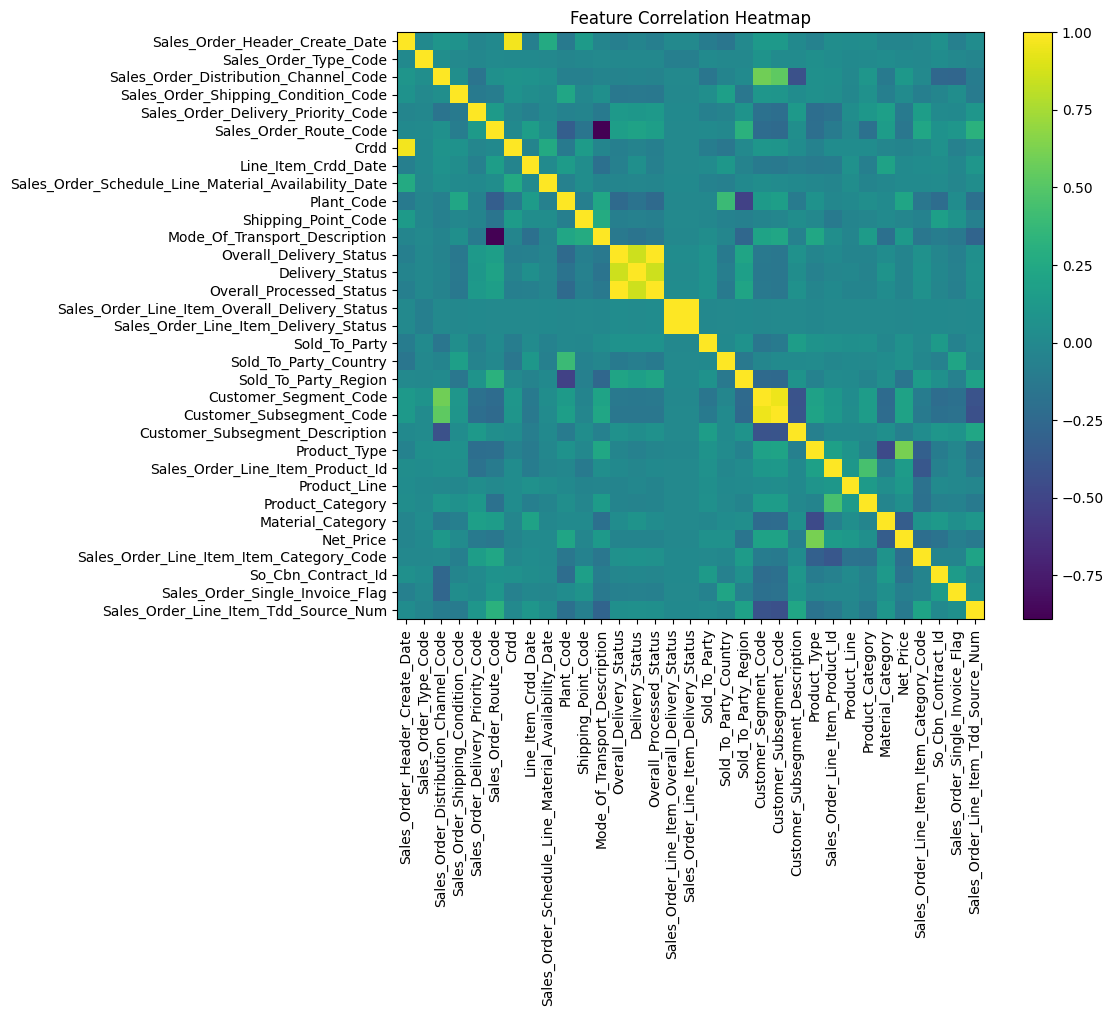

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation matrix
corr_matrix = X_corr.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()

# Add ticks
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### 5.1 Drop Highly Correlated Features

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Features to drop (correlation > 0.85)
# Crdd was removed earlier (replaced by relative date features)
drop_cols = [
    "Overall_Processed_Status",
    "Sales_Order_Line_Item_Delivery_Status",
    "Customer_Subsegment_Code",
    "Mode_Of_Transport_Description",
]

# Update feature lists
_cat = [c for c in _cat if c not in drop_cols]
_num = [c for c in _num if c not in drop_cols]

# Drop from train / test sets
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# Re-build and fit the preprocessor
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), _cat),
        ("num", "passthrough", _num),
    ]
)

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

print(f"Dropped features : {drop_cols}")
print(f"Remaining cat    : {len(_cat)}")
print(f"Remaining num    : {len(_num)}")
print(f"X_train_enc shape: {X_train_enc.shape}")
print(f"X_test_enc  shape: {X_test_enc.shape}")

Dropped features : ['Overall_Processed_Status', 'Sales_Order_Line_Item_Delivery_Status', 'Customer_Subsegment_Code', 'Mode_Of_Transport_Description']
Remaining cat    : 24
Remaining num    : 5
X_train_enc shape: (1922251, 109558)
X_test_enc  shape: (480563, 109558)


## 6. Model Training
### 6.1 XGBoost Regressor

In [0]:
from xgboost import XGBRegressor

xgb_model_reduced = XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_model_reduced.fit(X_train_enc, y_train)
from sklearn.metrics import mean_squared_error

preds = xgb_model_reduced.predict(X_test_enc)
rmse = mean_squared_error(y_test, preds, squared=False)

In [0]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = xgb_model_reduced.predict(X_test_enc)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE of XGBoost Regressor:", rmse)
print("R2 of XGBoost Regressor:", r2)

RMSE of XGBoost Regressor: 9.738991052846975
R2 of XGBoost Regressor: 0.9137836385693856


### 6.2 XGBoost Pipeline

In [0]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipe_reg = Pipeline(steps=[
    ("preprocess", preprocess),   # your existing encoder
    ("model", XGBRegressor(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ))
])

In [0]:
pipe_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sales_Order_Type_Code',
                                                   'Sales_Order_Distribution_Channel_Code',
                                                   'Sales_Order_Shipping_Condition_Code',
                                                   'Sales_Order_Delivery_Priority_Code',
                                                   'Sales_Order_Route_Code',
                                                   'Plant_Code',
                                                   'Shipping_Point_Code',
                                                   'Overall_Delivery_Status',
                                                   'Delivery_Status...
                              feature_types=None, gamma=None, gpu_id=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, n_estimators=700,
                              n_jobs=-1, num_parallel_tree=None, predictor=None,
                              random_state=42, ...))])

#### XGBoost Pipeline — Evaluation

In [0]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = pipe_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 9.738991052846975
R2: 0.9137836385693856


### 6.3 CatBoost Regressor

In [0]:
from catboost import CatBoostRegressor

cat_model_reduced = CatBoostRegressor(
    depth=8,
    learning_rate=0.05,
    iterations=1000,
    loss_function='RMSE',
    random_seed=42
)

cat_model_reduced.fit(X_train_enc, y_train, verbose=100)

0:	learn: 32.6109104	total: 194ms	remaining: 3m 13s
100:	learn: 13.4706222	total: 13.4s	remaining: 1m 59s
200:	learn: 12.3191970	total: 25.8s	remaining: 1m 42s
300:	learn: 11.6726074	total: 38.3s	remaining: 1m 28s
400:	learn: 11.2136461	total: 51.5s	remaining: 1m 16s
500:	learn: 10.8806004	total: 1m 4s	remaining: 1m 3s
600:	learn: 10.6079381	total: 1m 16s	remaining: 51.1s
700:	learn: 10.3641116	total: 1m 29s	remaining: 38.2s
800:	learn: 10.1602873	total: 1m 41s	remaining: 25.3s
900:	learn: 9.9840972	total: 1m 54s	remaining: 12.6s
999:	learn: 9.8112498	total: 2m 6s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42)

In [0]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = cat_model_reduced.predict(X_test_enc)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE of CatBoostRegressor:", rmse)
print("R2 of CatBoostRegressor:", r2)

RMSE of CatBoostRegressor: 9.864959824877145
R2 of CatBoostRegressor: 0.9115388871327748


### 6.4 LightGBM Regressor

In [0]:
from lightgbm import LGBMRegressor

lgbm_model_reduced = LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=40,
    random_state=42
)

lgbm_model_reduced.fit(X_train_enc, y_train)

[{"name": "PREPROCESSED_PATH", "variableType": "str", "value": "/Workspace/Users/suhani.thakur@hp.com/Shared/preprocessed_data/preprocessed_data.parquet", "schema": "", "shape": ""}, {"name": "X", "variableType": "DataFrame", "value": " Sales_Order_Header_Create_Date Sales_Order_Type_Code Sales_Order_Distribution_Channel_Code Sales_Order_Shipping_Condition_Code Sales_Order_Delivery_Priority_Code Sales_Order_Route_Code  Crdd  Line_Item_Crdd_Date  Sales_Order_Schedule_Line_Material_Availability_Date Plant_Code Shipping_Point_Code Mode_Of_Transport_Description Overall_Delivery_Status Delivery_Status Overall_Processed_Status Sales_Order_Line_Item_Overall_Delivery_Status Sales_Order_Line_Item_Delivery_Status Sold_To_Party Sold_To_P... (truncated)", "schema": "['Sales_Order_Header_Create_Date', 'Sales_Order_Type_Code', 'Sales_Order_Distribution_Channel_Code', 'Sales_Order_Shipping_Condition_Code', 'Sales_Order_Delivery_Priority_Code', 'Sales_Order_Route_Code', 'Crdd', 'Line_Item_Crdd_Date', 

LGBMRegressor(learning_rate=0.05, n_estimators=600, num_leaves=40,
              random_state=42)

In [0]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lgbm_model_reduced.predict(X_test_enc)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE of LightGBM Regressor:", rmse)
print("R2 of LightGBM Regressor:", r2)

RMSE of LightGBM Regressor: 9.223146787561898
R2 of LightGBM Regressor: 0.9226749876811476


## 7. Model Comparison (RMSE & R²)

In [0]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = {}

def evaluate(name, model):
    y_pred = model.predict(X_test_enc)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2   = r2_score(y_test, y_pred)
    results[name] = {"RMSE": rmse, "R2": r2}

# Evaluate all trained models
evaluate("LightGBM", lgbm_model_reduced)
evaluate("XGBoost", xgb_model_reduced)
#evaluate("RandomForest", rf_model)

evaluate("CatBoost", cat_model_reduced)

# Convert to DataFrame for display
comparison_df = pd.DataFrame(results).T

print("\n=== Model Comparison (RMSE & R2) ===")
print(comparison_df)

print("\n=== Ranked by RMSE (lower is better) ===")
print(comparison_df.sort_values("RMSE"))


=== Model Comparison (RMSE & R2) ===
              RMSE        R2
LightGBM  9.223147  0.922675
XGBoost   9.738991  0.913784
CatBoost  9.864960  0.911539

=== Ranked by RMSE (lower is better) ===
              RMSE        R2
LightGBM  9.223147  0.922675
XGBoost   9.738991  0.913784
CatBoost  9.864960  0.911539


## 8. Feature Importance

### 8.1 Permutation Importance

In [0]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_result = permutation_importance(
    pipe_reg,
    X_test,              
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

# Feature names = original columns
feature_names = X_test.columns

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(perm_df.head(20))

                                              feature  ...  importance_std
8   Sales_Order_Schedule_Line_Material_Availabilit...  ...        0.041644
0                      Sales_Order_Header_Create_Date  ...        0.016250
7                                 Line_Item_Crdd_Date  ...        0.024923
6                                                Crdd  ...        0.010852
26                                 So_Cbn_Contract_Id  ...        0.007026
14                                      Sold_To_Party  ...        0.007895
5                              Sales_Order_Route_Code  ...        0.004830
15                              Sold_To_Party_Country  ...        0.042660
16                               Sold_To_Party_Region  ...        0.002836
27                    Sales_Order_Single_Invoice_Flag  ...        0.030050
4                  Sales_Order_Delivery_Priority_Code  ...        0.028453
18                    Customer_Subsegment_Description  ...        0.026673
28               Sales_Or

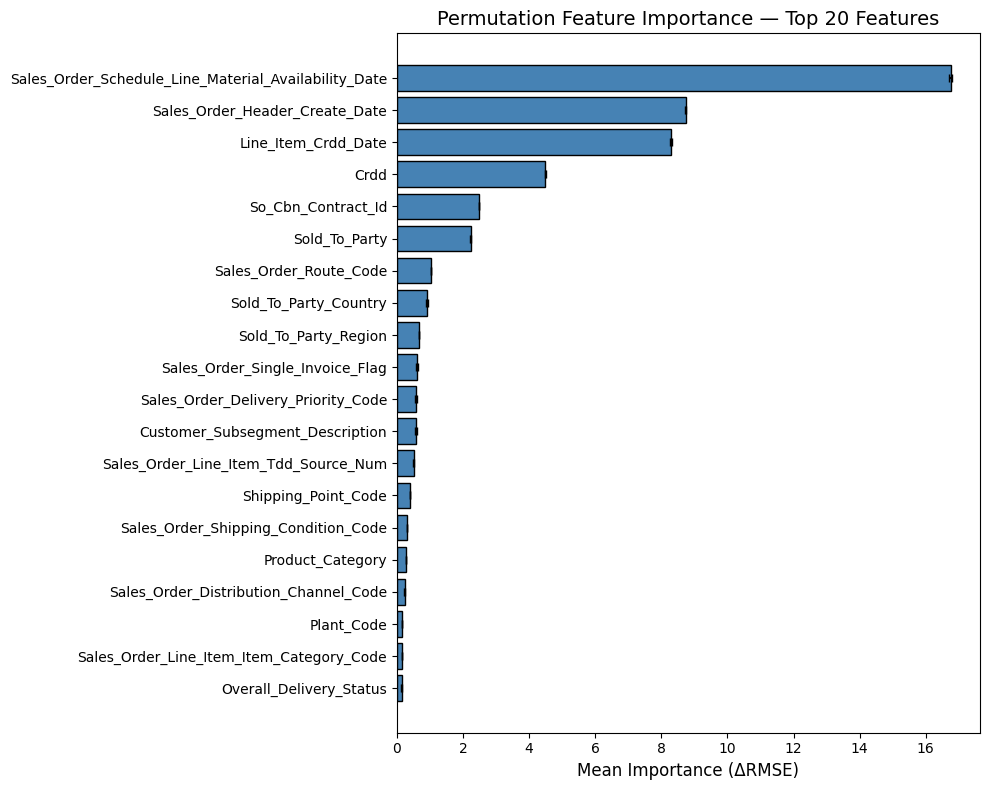

In [0]:
import matplotlib.pyplot as plt

top_n = 20
top_features = perm_df.head(top_n).sort_values(by="importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    color="steelblue",
    edgecolor="black",
    capsize=3
)
ax.set_xlabel("Mean Importance (ΔRMSE)", fontsize=12)
ax.set_title("Permutation Feature Importance — Top 20 Features", fontsize=14)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning

### 9.1 XGBoost — Randomized Search

In [0]:
# file: xgb_tuning_with_progress.py

import numpy as np
import os
import time
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

# ---- GLOBAL SETTINGS ----
os.environ["OMP_NUM_THREADS"] = "8"

# ---- PROGRESS WRAPPER ----
class ProgressXGBRegressor(XGBRegressor):
    def fit(self, X, y, **kwargs):
        start = time.time()
        print(f"[START] Training model with params: {self.get_params()}", flush=True)
        
        result = super().fit(X, y, **kwargs)
        
        duration = time.time() - start
        print(f"[END] Model done in {duration:.2f} sec\n", flush=True)
        return result

# ---- BASE MODEL ----
xgb_base = ProgressXGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=8,
    random_state=42
)

# ---- PARAM SPACE ----
param_dist_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

# ---- CV ----
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# ---- SEARCH ----
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=3,
    n_jobs=2,
    pre_dispatch=2,
    random_state=42,
    return_train_score=False
)

# ---- DATA PREP ----
X_train_enc = X_train_enc.astype('float32')

# ---- START ----
print("Starting hyperparameter tuning...", flush=True)
print(f"Total iterations: {xgb_random.n_iter} | CV folds: {cv.get_n_splits()}", flush=True)

start_time = time.time()

# ---- FIT ----
xgb_random.fit(X_train_enc, y_train)

total_time = time.time() - start_time
print(f"Tuning completed in {total_time/60:.2f} minutes", flush=True)

# ---- RESULTS ----
print("Best params:", xgb_random.best_params_)
print("Best CV RMSE:", -xgb_random.best_score_)

Starting hyperparameter tuning...
Total iterations: 30 | CV folds: 3
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[START] Training model with params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'gpu_id': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': 3, 'missing': nan, 'monotone_constraints': None, 'n_estimators': 300, 'n_jobs': 8, 'num_parallel_tree': None, 'predictor': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 10, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_method': 'hist', '

### 9.2 Train Final Model with Best Parameters

In [0]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, callback

# ---- CONFIG ----
CHECKPOINT_DIR = "/Workspace/Users/suhani.thakur@hp.com/Shared/xgb_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---- SMALL EVAL SET ----
X_train_full, X_val_small, y_train_full, y_val_small = train_test_split(
    X_train_enc,
    y_train,
    test_size=50000,
    random_state=42
)

# ---- CUSTOM CHECKPOINT CALLBACK ----
class SaveCheckpoint(callback.TrainingCallback):
    def __init__(self, save_every=5):
        self.save_every = save_every
        self.best_score = float("inf")
        self.best_iter = 0

    def after_iteration(self, model, epoch, evals_log):
        rmse = evals_log["validation_0"]["rmse"][-1]

        # save best model
        if rmse < self.best_score:
            self.best_score = rmse
            self.best_iter = epoch
            model.save_model(f"{CHECKPOINT_DIR}/best_model_f.json")
            print(f"New best RMSE: {rmse:.5f} at iter {epoch}", flush=True)

        # periodic checkpoint
        if epoch % self.save_every == 0:
            model.save_model(f"{CHECKPOINT_DIR}/model_2iter_{epoch}.json")
            print(f"Saved checkpoint at iter {epoch}", flush=True)

        return False  # continue training

# ---- MODEL ----
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=8,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

# ---- TRAIN ----
checkpoint_cb = SaveCheckpoint(save_every=50)

xgb_model.fit(
    X_train_full,
    y_train_full,
    eval_set=[(X_val_small, y_val_small)],
    eval_metric="rmse",
    early_stopping_rounds=10,
    callbacks=[checkpoint_cb],
    verbose=3
)

# ---- FINAL INFO ----
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best RMSE: {xgb_model.best_score}")

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `callbacks` in `fit` method is deprecated for better compatibility with scikit-learn, use `callbacks` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:34.44029
New best RMSE: 34.44029 at iter 0
Saved checkpoint at iter 0
New best RMSE: 33.00023 at iter 1
New best RMSE: 31.64680 at iter 2
[3]	validation_0-rmse:30.39217
New best RMSE: 30.39217 at iter 3
New best RMSE: 29.21424 at iter 4
New best RMSE: 28.13374 at iter 5
[6]	validation_0-rmse:27.09241
New best RMSE: 27.09241 at iter 6
New best RMSE: 26.15065 at iter 7
New best RMSE: 25.26718 at iter 8
[9]	validation_0-rmse:24.41163
New best RMSE: 24.41163 at iter 9
New best RMSE: 23.63143 at iter 10
New best RMSE: 22.85618 at iter 11
[12]	validation_0-rmse:22.14747
New best RMSE: 22.14747 at iter 12
New best RMSE: 21.48500 at iter 13
New best RMSE: 20.86663 at iter 14
[15]	validation_0-rmse:20.24979
New best RMSE: 20.24979 at iter 15
New best RMSE: 19.71963 at iter 16
New best RMSE: 19.19317 at iter 17
[18]	validation_0-rmse:18.69082
New best RMSE: 18.69082 at iter 18
New best RMSE: 18.24733 at iter 19
New best RMSE: 17.82376 at iter 20
[21]	validation_0-rmse:17.42

### 9.3 Resume Training from Checkpoint

In [0]:
from xgboost import XGBRegressor, callback
import os

CHECKPOINT_DIR = "/Workspace/Users/suhani.thakur@hp.com/Shared/xgb_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

class SaveCheckpoint(callback.TrainingCallback):
    def __init__(self, save_every=50):
        self.save_every = save_every
        self.best_score = float("inf")
        self.best_iter = 0

    def before_training(self, model):
        if hasattr(model, "best_score"):
            self.best_score = model.best_score
            self.best_iter = model.best_iteration
        return model


model = XGBRegressor()
model.load_model(f"{CHECKPOINT_DIR}/best_model_f.json")

model.set_params(n_estimators=300)
checkpoint_cb = SaveCheckpoint(save_every=25)
model.fit(
    X_train_full,
    y_train_full,
    eval_set=[(X_val_small, y_val_small)],
    eval_metric="rmse",
    early_stopping_rounds=100,
    xgb_model=model,
    verbose=1
)

# Save the final resumed model
save_path = f"{CHECKPOINT_DIR}/best_model_f_final.json"
model.save_model(save_path)
print(f"\nSaved resumed model to {save_path}")

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:782: UserWarning: Loading a native XGBoost model with Scikit-Learn interface.
  warnings.warn("Loading a native XGBoost model with Scikit-Learn interface.")
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:11.19789
[1]	validation_0-rmse:11.13463
[2]	validation_0-rmse:11.09107
[3]	validation_0-rmse:11.05972
[4]	validation_0-rmse:10.95269
[5]	validation_0-rmse:10.91798
[6]	validation_0-rmse:10.89889
[7]	validation_0-rmse:10.87032
[8]	validation_0-rmse:10.84848
[9]	validation_0-rmse:10.82194
[10]	validation_0-rmse:10.79440
[11]	validation_0-rmse:10.77501
[12]	validation_0-rmse:10.74989
[13]	validation_0-rmse:10.73106
[14]	validation_0-rmse:10.64494
[15]	validation_0-rmse:10.63367
[16]	validation_0-rmse:10.61975
[17]	validation_0-rmse:10.58369
[18]	validation_0-rmse:10.56719
[19]	validation_0-rmse:10.53958
[20]	validation_0-rmse:10.53145
[21]	validation_0-rmse:10.50329
[22]	validation_0-rmse:10.47764
[23]	validation_0-rmse:10.45934
[24]	validation_0-rmse:10.42996
[25]	validation_0-rmse:10.41510
[26]	validation_0-rmse:10.39844
[27]	validation_0-rmse:10.37863
[28]	validation_0-rmse:10.36393
[29]	validation_0-rmse:10.34928
[30]	validation_0-rmse:10.32257
[31]	validation_0-

### 9.5 Evaluate Tuned Model on Test Set

In [0]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Load best model
best_model = XGBRegressor()
best_model.load_model("/Workspace/Users/suhani.thakur@hp.com/Shared/xgb_checkpoints/best_model_f_final.json")

# Predict on test set
test_preds = best_model.predict(X_test_enc)

# Metrics
test_rmse = mean_squared_error(y_test, test_preds, squared=False)
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"{'='*45}")
print(f"  Test Set Evaluation (best_model1.json)")
print(f"{'='*45}")
print(f"  RMSE : {test_rmse:.4f}")
print(f"  MAE  : {test_mae:.4f}")
print(f"  R2   : {test_r2:.4f}")
print(f"{'='*45}")

  Test Set Evaluation (best_model1.json)
  RMSE : 8.4329
  MAE  : 4.1295
  R2   : 0.9354
